# Task 8.1: QASM 타입 및 구조 (QASM Types and Structures)

QASM (Quantum Assembly Language, 양자 어셈블리 언어)는 양자 회로(quantum circuit)와 연산을 기술하기 위해 설계된 저수준(low-level) 프로그래밍 언어입니다. Qiskit과 같은 고수준 양자 프로그래밍 언어와 실제 양자 하드웨어 사이를 이어주는 중간 표현(intermediate representation) 역할을 합니다.

이 노트북에서는 QASM에서 사용할 수 있는 타입(Type)들과, 이 타입들 사이의 캐스팅(casting) 규칙을 다룹니다.

QASM 예제는 [OpenQASM 3 공식 문서](https://openqasm.com/) 를 기반으로 합니다. 양자 회로가 들어 있는 예제는 qiskit 으로 불러와 회로도까지 함께 그려 봅니다.


## 환경 설정 (Setup)

이 노트북은 양자 회로 예제를 시각화하기 위해 [`qiskit`](https://qiskit.org/) 의 OpenQASM 3 로더를 사용합니다. 타입 선언과 캐스팅 등 고전 부분은 코드 자체로 학습하고, 실제 회로가 들어 있는 예제만 qiskit 으로 로드해 회로도를 그립니다.


In [ ]:
# 필요한 패키지 설치 (한 번만)
# !pip install qiskit qiskit-qasm3-import matplotlib pylatexenc

from qiskit.qasm3 import loads

print('준비 완료.')


## 목표 1 : QASM 타입과 캐스팅 (QASM Types and Casting)

### 식별자 (Identifiers)

* 시작 문자: `[A-Za-z]`, 언더스코어(`_`), 또는 유니코드 문자 범주 `Lu/Ll/Lt/Lm/Lo/Nl` 중 하나
* 연속 문자: 시작 문자 + 십진수 `[0-9]`
* 예약 식별자: 예약된 키워드나 내장 함수 이름은 식별자로 사용할 수 없음
* 예시:
    - 유효: `myQubit`, `_temp`, `θ` (그리스 문자 세타), `qubit1`, `result_2`
    - 무효: `qubit@1`, `1qubit`, `qubit` (예약어)

### 변수 (Variables)

* 식별자 규칙에 따라 이름이 정해집니다
* 프로그램 내에서 값을 할당할 수 있습니다
* 고전(classical) 타입은 선언과 동시에 초기화가 가능합니다
* 선언과 초기화는 한 번에 하나의 변수씩 처리해야 합니다

예시: 양자 변수 선언 (Quantum Variable Declaration)

In [2]:
qasm_quantum_decl = """
OPENQASM 3.0;

// q0, q1, q2 라는 이름의 단일 큐비트 3개를 선언합니다
qubit q0;
qubit q1;
qubit q2;
"""


예시: 고전 변수 선언과 초기화 (Classical Variable Declaration and Initialization)

In [3]:
qasm_classical_decl = """
OPENQASM 3.0;

// 32비트 부호 있는 정수, 초기화하지 않음
int[32] a;
// 32비트 부동소수점, 5.5 로 초기화
float[32] b = 5.5;
// 3비트 레지스터, 초기화하지 않음
bit[3] c;
// false 로 초기화한 Boolean 변수
bool my_bool = false;
"""


### 양자 타입 (Quantum Types)

#### 큐비트 (Qubits)

* 단일 큐비트: `qubit`
* 큐비트 레지스터: `qubit[size]` (큐비트 배열)
* 사용 중단(Deprecated): `qreg`는 하위 호환성을 위해 남아 있으며, 향후 버전에서 제거됩니다
* 전역(Global): 양자 변수는 항상 전역 범위입니다

예시: 상수 크기를 갖는 큐비트 레지스터

In [5]:
qasm_qubit_register = """
OPENQASM 3.0;
include "stdgates.inc";

include "stdgates.inc";

// Declares 5-qubit register called q1
qubit[5] q1;
// Compile-time constant
const uint SIZE = 4;
uint runtime_u = 2;
// Declares 4-qubit register using constant
qubit[SIZE] q2;

// Apply X gate to first qubit of q1
x q1[0];                  
// Apply Z gate to third qubit of q2 (4-2=2)
z q2[SIZE - 2];
// Apply X gate to third qubit of q1 (index 2)
x q1[runtime_u];
"""


#### 물리 큐비트 (Physical Qubits)

* 문법: `$0`, `$1`, `$2` 등으로 참조
* 선언 불가: 물리 큐비트는 하드웨어에 의해 미리 정의되어 있어 직접 선언하지 않습니다
* 전역: 프로그램 전체에서 접근 가능
* 목적: 물리 하드웨어 큐비트를 직접 주소 지정할 때 사용

예시: 물리 큐비트 주소 지정

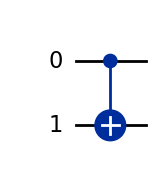

In [6]:
qasm_physical_qubit = """
OPENQASM 3.0;
include "stdgates.inc";

// 물리 큐비트 0 과 1 사이에 CX
cx $0, $1;
"""
loads(qasm_physical_qubit).draw("mpl")


### 고전 스칼라 타입 (Classical Scalar Types)

#### 고전 비트와 레지스터 (Classical Bits and Registers)

* 단일 비트: `bit`
* 비트 레지스터: `bit[size]`
* 사용 중단: `creg`는 향후 제거됩니다

예시: 비트 연산

In [7]:
qasm_bit_ops = """
OPENQASM 3.0;

// 20비트 레지스터
bit[20] bit_array;
// 비트 문자열로 초기화한 8비트 레지스터
bit[8] name = "00001111";
"""


#### 정수 (Integers)

* 부호 있음: `int[size]` 또는 `int` (구현체에 따라 크기 결정)
* 부호 없음: `uint[size]` 또는 `uint`
* 비트 연산: 명시적인 폭(width) 지정이 필요합니다

예시: 정수 연산과 캐스팅

In [8]:
qasm_int_cast = """
OPENQASM 3.0;

// 32비트 부호 없는 정수
uint[32] my_uint = 10;
// 16비트 부호 있는 정수
int[16] my_int;
// uint[32] 에서 int[16] 으로 명시적 캐스팅
my_int = int[16](my_uint);
"""


#### 부동소수점 수 (Floating Point Numbers)

* 크기 명시: `float[size]`
* 하드웨어 종속: `float` (대상 아키텍처에 따라 정밀도 결정)

예시: 부동소수점 값

In [9]:
qasm_float = """
OPENQASM 3.0;

// pi 상수로 초기화한 32비트 float
float[32] my_float = π;
// 머신 정밀도 float
float my_machine_float = 2.3;
"""


#### Void 타입

* 사용처: 값을 반환하지 않는 함수의 반환 타입으로 사용

#### 각도 (Angles)

* 형식: `angle[size]`, 여기서 1 단위 = 2π / 2^size
* 표현 범위: [0, 2π) — 즉 한 바퀴(원 위의 한 점)를 size 비트로 균등 분할한 fixed-point 값
* 산술: 내부적으로 부호 없는 정수 산술(unsigned integer arithmetic) 을 사용합니다

##### 왜 굳이 별도의 `angle` 타입이 필요할까?

`float` 만 있어도 각도를 충분히 다룰 수 있을 것 같지만, OpenQASM 3 가 새로 도입한 핵심 타입 중 하나가 바로 이 `angle` 입니다. 그 이유는 이 언어가 다루는 대상이 양자 하드웨어 직전 단계의 고전 제어 시스템 이기 때문입니다.

1. 양자 제어 하드웨어는 부동소수점 연산을 지원하지 않을 수 있다

OpenQASM 3 는 단순히 회로를 기술하는 것을 넘어 실시간 피드백 제어(measurement → 분기 → 다음 게이트의 각도 결정)를 지원합니다. 이 실시간 경로를 처리하는 FPGA/ASIC 컨트롤러는 회로 설계 비용 때문에 부동소수점 ALU 자체가 없는 경우가 많습니다. 모든 실시간 산술이 정수 연산으로 처리돼야 하므로, 각도 역시 정수 기반(fixed-point)으로 표현하는 게 자연스럽습니다.

2. 각도는 태생적으로 modular 값이다 ([0, 2π) 위의 ring)

θ 와 θ + 2π 는 양자역학적으로 완전히 같은 위상입니다. 이 modular 성질을 `float` 으로 다루려면 매번 `fmod(theta, 2π)` 같은 비싼 연산이 필요합니다. 반면 fixed-point `angle[n]` 은 n비트 unsigned 정수의 자연스러운 오버플로우(wrap-around) 가 곧 `mod 2π` 와 같습니다. 추가 연산이 0개 — 그냥 더하면 알아서 wrap 됩니다.

3. NCO(Numerically-Controlled Oscillator) 와 정확히 같은 형식

실제 양자 컨트롤러에서 큐비트의 회전 프레임(rotating frame)을 추적하는 방식이 바로 NCO 인데, 이는 본질적으로 누적기(phase accumulator)에 매 사이클마다 정수를 더해 위상을 갱신합니다. `angle[n]` 의 표현 방식은 이 NCO 의 데이터 형식과 일대일로 대응되어 컴파일 시 별도 변환 없이 그대로 하드웨어에 매핑됩니다.

4. QFT/QPE 같은 양자 알고리즘과 자연스럽게 들어맞는다

[양자 푸리에 변환(QFT)](https://en.wikipedia.org/wiki/Quantum_Fourier_transform) 과 양자 위상 추정(QPE)에 등장하는 회전각은 모두 2의 거듭제곱 분수의 π 형태 (π, π/2, π/4, π/8, ...) 입니다. 즉 `angle[n]` 의 비트 하나하나가 정확히 이런 회전들에 대응합니다 — 측정으로 얻은 비트 패턴을 그대로 angle 변수에 넣으면 곧장 회전각이 되는 식입니다. 역 QFT 의 자연스러운 표현이 바로 여기서 나옵니다.

##### 표현 방식: fixed-point 비트 인코딩

`angle[n]` 은 [0, 2π) 구간을 `2^n` 등분합니다. n 비트 unsigned 정수 `k` 가 들어 있다면 그 값은:

$$\theta = 2\pi \times \frac{k}{2^n}$$

대표적인 예:

| 타입       | 1 단위        | π 의 표현    | π/2 의 표현 |
|------------|---------------|--------------|-------------|
| `angle[4]` | 2π/16 = π/8   | 8  → `1000` | 4  → `0100` |
| `angle[6]` | 2π/64 = π/32  | 32 → `100000` | 16 → `010000` |
| `angle[8]` | 2π/256 = π/128| 128 → `10000000` | 64 → `01000000` |

예시: 각도 선언과 표현

In [10]:
qasm_angle = """
OPENQASM 3.0;

// π/2 를 표현하는 20비트 각도
angle[20] my_angle_a = π / 2;
// 머신 정밀도 각도
angle my_machine_angle;

// 이진수 "1000" (π 를 4비트로 표현)
// 1 단위 = 2π/2^4 = 2π/16 = π/8
// π = 8 단위 = "1000"
angle[4] my_pi = π;

// 이진수 "010000" (π/2 를 6비트로 표현)
// 1 단위 = 2π/2^6 = 2π/64 = π/32
// π/2 = 16 단위 = "010000"
angle[6] my_pi_over_two = π/2;

// 이진수 "01110000" (8비트 표현)
// 1 단위 = 2π/2^8 = 2π/256 = π/128
// 7*π/8 = 112 단위 = "01110000"
angle[8] my_angle_b = 7 * (π / 8);
"""


##### Python 으로 비트 표현 직접 확인하기

`angle[n]` 의 fixed-point 인코딩이 어떻게 동작하는지, Python 으로 시뮬레이션해보면 직관이 잡힙니다.

In [11]:
import math
from openqasm3.parser import parse
from openqasm3 import ast


def eval_const(node):
    """간단한 OpenQASM 상수 표현식 평가 (π/τ/e, 리터럴, 단항/이항 산술)."""
    if isinstance(node, ast.IntegerLiteral):
        return node.value
    if isinstance(node, ast.FloatLiteral):
        return node.value
    if isinstance(node, ast.Identifier):
        return {"π": math.pi, "pi": math.pi,
                "τ": 2 * math.pi, "tau": 2 * math.pi,
                "e": math.e, "ℇ": math.e}[node.name]
    if isinstance(node, ast.UnaryExpression):
        v = eval_const(node.expression)
        return -v if node.op.name == "-" else v
    if isinstance(node, ast.BinaryExpression):
        a, b = eval_const(node.lhs), eval_const(node.rhs)
        return {"+": a + b, "-": a - b, "*": a * b,
                "/": a / b, "**": a ** b}[node.op.name]
    raise ValueError(f"평가 불가: {type(node).__name__}")


def angle_encode(theta: float, n: int) -> int:
    """실수 theta (라디안) 를 angle[n] 의 정수 표현으로 인코딩 (자동 mod 2π)."""
    return round(theta / (2 * math.pi) * (1 << n)) % (1 << n)


# 위 QASM 셀에서 정의한 qasm_angle 문자열을 그대로 파싱
program = parse(qasm_angle)

print("=== 위 QASM 셀의 angle 변수 → 실제 비트 표현 ===\n")
print(f"{'변수':<20} {'타입':<12} {'정수':>6}    {'비트열':<22} {'값':>10}")
print("-" * 72)

for stmt in program.statements:
    if not isinstance(stmt, ast.ClassicalDeclaration):
        continue
    if not isinstance(stmt.type, ast.AngleType):
        continue

    name = stmt.identifier.name
    n = eval_const(stmt.type.size) if stmt.type.size is not None else None
    type_str = f"angle[{n}]" if n is not None else "angle"

    if stmt.init_expression is None:
        print(f"{name:<20} {type_str:<12} {'-':>6}    {'(초기화 없음)':<22}")
        continue

    theta = eval_const(stmt.init_expression)
    k = angle_encode(theta, n)
    bits = format(k, f"0{n}b")
    print(f"{name:<20} {type_str:<12} {k:>6}    0b{bits:<20} {theta/math.pi:>9.4f}π")

=== 위 QASM 셀의 angle 변수 → 실제 비트 표현 ===

변수                   타입               정수    비트열                             값
------------------------------------------------------------------------
my_angle_a           angle[20]    262144    0b01000000000000000000    0.5000π
my_machine_angle     angle             -    (초기화 없음)              
my_pi                angle[4]          8    0b1000                    1.0000π
my_pi_over_two       angle[6]         16    0b010000                  0.5000π
my_angle_b           angle[8]        112    0b01110000                0.8750π


##### `angle` 연산: 자동 modular arithmetic

`angle[n]` 끼리의 덧셈·뺄셈은 n비트 unsigned 정수 연산과 동일한 비트 패턴을 만듭니다. 즉, `mod 2π` 가 공짜로 적용됩니다.

OpenQASM 3 명세에 명시된 동작:
- `a + b` : 같은 크기 angle 끼리 덧셈, 오버플로우는 자동 wrap (정수 오버플로우와 동일)
- `a - b` : 뺄셈, 언더플로우도 마찬가지로 wrap
- `uint * angle`, `angle / uint` : angle 결과
- `angle / angle` : uint 결과 (배수)
- `angle << k`, `angle >> k` : 비트 시프트 (uint 처럼 동작)
- `-a` : `0 - a` 와 동일 (보수)

In [12]:
qasm_angle_arith = """
OPENQASM 3.0;

// "0111" = 7π/8
angle[4] a = 7 * (π / 8);
// "0001" = π/8
angle[4] b = π / 8;
// "1010" = 5π/4
angle[4] c = 5 * (π / 4);
uint[4] two = 2;

// 7π/8 + π/8 = π = "1000" (오버플로우 없음)
angle[4] r1 = a + b;
// π/8 - 7π/8 = -6π/8  →  wrap →  10π/8 = 5π/4 = "1010"
angle[4] r2 = b - a;
// 7π/8 / 2 = 7π/16  ≈  3π/8 (분해능 한계로 잘림) = "0011"
angle[4] r3 = a / two;
// 2 * 5π/4 = 10π/4 = 5π/2  →  wrap →  π/2 = "0100"
angle[4] r4 = two * c;
// π * 2 = 2π  →  wrap →  0 = "0000"
angle[4] r5 = π * 2;

// 단항 부정: -π/4 → 7π/4 = "1110"
angle[4] d = π / 4;
angle[4] neg_d = -d;
"""


In [ ]:
from qiskit.qasm3 import loads

loads("""
OPENQASM 3.0;
include "stdgates.inc";
qubit[1] q;
angle[3] theta = π;
rz(theta) q[0];
""")
# → QASM3ImporterError

QASM3ImporterError: "5,0: declarations of type 'angle' are not supported"

#### 복소수 (Complex Numbers)

* 형식: `complex[float[size]]`
* 허수 단위: `im` 접미사 (예: `3.5im`)
* 추출: `real()`, `imag()` 함수
* 하드웨어 지원: 실제 양자 하드웨어에서는 지원되지 않을 수 있습니다

예시: 복소수 연산

In [14]:
qasm_complex = """
OPENQASM 3.0;

// 64비트 복소수
complex[float[64]] c;
// 실수부와 허수부 할당
c = 2.5 + 3.5im;
// 복소 표현식
complex[float] d = 2.0 + sin(π/2) + (3.1 * 5.5 im);
// 실수부 추출: ~3.0
float d_real = real(d);
// 허수부 추출: ~17.05
float d_imag = imag(d);
"""


#### Boolean 타입

* 값: `true` 또는 `false`
* 캐스팅: `bool()`을 사용해 `bit`에서 변환 가능

예시: Boolean 연산

In [15]:
qasm_bool = """
OPENQASM 3.0;

bit my_bit = 0;
bool my_bool;
// bit 를 boolean 으로 변환 (0 → false)
my_bool = bool(my_bit);
// 직접 할당
my_bool = true;
"""


### 컴파일 시점 상수 (Compile Time Constants)

* 키워드: `const`
* 타입의 폭(width)을 지정할 때 필요합니다
* 모든 스칼라 리터럴은 암묵적으로 `const` 입니다

예시: 올바른 상수 사용

In [16]:
qasm_const_valid = """
OPENQASM 3.0;

const uint SIZE = 32;
// 32큐비트 레지스터 (상수 사용)
qubit[SIZE] q1;
// 32비트 정수 변수
int[SIZE] i1;
"""


예시: 잘못된 런타임 크기 사용

아래 코드는 의미적으로 잘못된 예시입니다. `runtime_size` 는 `const` 가 아니므로 타입의 폭(width)으로 사용할 수 없습니다. OpenQASM 컴파일러가 거부할 코드입니다.


In [17]:
qasm_const_invalid = """
OPENQASM 3.0;

// 런타임 변수 (const 가 아님)
uint runtime_size = 32;
// runtime_size 는 const 가 아니므로 의미적으로 잘못됨
// → 파서는 문법만 보므로 통과, 컴파일러가 나중에 거부
qubit[runtime_size] q2;
int[runtime_size] i2;
"""


예시: 상수 표현식

In [18]:
qasm_const_expr = """
OPENQASM 3.0;

// 상수 float
const float[64] f1 = 2.5;
uint[8] runtime_u = 7;

// OK: f1 은 상수, i1 = 2 (잘림)
const int[8] i1 = int[8](f1);
// OK: u1 = 4  (2 * uint(2.5) = 2 * 2 = 4)
const uint u1 = 2 * uint(f1);
"""

# 아래는 의도적으로 잘못된 예시 (학습용)
qasm_const_expr_invalid = """
OPENQASM 3.0;

const float[64] f1 = 2.5;
uint[8] runtime_u = 7;

// 잘못됨: float[64] 는 bit[2] 로 캐스팅 불가
const bit[2] b1 = bit[2](f1);
// 잘못됨: runtime_u 는 상수가 아님
const int[16] i2 = int[16](runtime_u);
"""


#### 내장 상수 (Built-in Constants)

* 수학 상수: `π` (pi), `τ` (tau = 2π), `e` (자연상수)

#### 내장 상수 표현식 함수 (Built-in Constant Expression Functions)

* 삼각함수: `cos`, `sin`, `tan`, `arccos`, `arcsin`, `arctan`
* 반올림: `ceiling`, `floor`
* 지수/로그: `exp`, `log`
* 거듭제곱/나머지: `mod`, `pow`, `sqrt`
* 비트 조작: `popcount` (1로 설정된 비트 수 세기), `rotl`, `rotr` (왼쪽/오른쪽 회전)

### 리터럴 (Literals)

* 정수:
  - 십진수: `123`, `456`
  - 16진수: `0x1F`, `0xFF`, `0x1_F` (가독성을 위해 언더스코어 사용 가능)
  - 8진수: `0o77`
  - 2진수: `0b1010`, `0B1100`, `0b1_0101_1010`
  - 큰 값: `1_000_000` (가독성을 위해 언더스코어 사용 가능)

* 부동소수점:
  - 소수 표기: `3.14`, `.5`, `2.`
  - 과학적 표기법: `1e10`, `2e+1`, `2.0E-1`, `3.14e0`

* Boolean: `true`, `false`

* 비트 문자열: `"0101"`, `"1111_0000"` (언더스코어 허용)

* 시간:
  - `10ns` (나노초)
  - `2μs` 또는 `2us` (마이크로초)
  - `5ms` (밀리초)
  - `1s` (초)
  - `100dt` (장치 종속 시간 단위)

### 배열 (Arrays)

* 정적 크기: 컴파일 시점에 크기가 결정됩니다
* 문법: `array[base_type, dimension1, dimension2, ...]`
* 제한: 함수나 게이트 내부에서는 선언할 수 없습니다
* 최대 차원: 7

예시: 배열 선언과 접근

In [19]:
qasm_array = """
OPENQASM 3.0;

// 정수 5개로 이루어진 1D 배열
array[int[32], 5] myArray = {0, 1, 2, 3, 4};
// 3x2 2D 배열
array[float[32], 3, 2] multiDim = {
    {1.1, 1.2},
    {2.1, 2.2},
    {3.1, 3.2}
};

// 첫 번째 원소 접근: 0
int[32] firstElem = myArray[0];
// 마지막 원소 접근: 4
int[32] lastElem = myArray[4];
// 음수 인덱싱: 마찬가지로 4
int[32] alsoLastElem = myArray[-1];
// [1, 0] 위치 원소 접근: 2.1
float[32] row2col1 = multiDim[1, 0];
"""


### 타이밍 (Timing)

#### 지속 시간 (Duration)

* 목적: 시간 간격 표현
* 단위: `ns`, `μs`/`us`, `ms`, `s`, `dt` (장치 종속 단위)
* 연산: 덧셈, 뺄셈, 비교 가능

예시: Duration 연산

In [20]:
qasm_duration = """
OPENQASM 3.0;

duration one_second = 1000ms;          // 1000 밀리초 = 1초
duration thousand_cycles = 1000dt;     // 장치 종속 타이밍
duration two_seconds = one_second + 1s; // 산술: 1s + 1s = 2s
duration c = durationof({x $3;});      // 게이트 시퀀스의 지속 시간 측정
// 참고: dt 단위는 양자 하드웨어 백엔드에 따라 달라집니다
"""


#### Stretch (신축형 지속 시간)

* 하위 타입: 특수 목적의 duration 타입
* 해상도: 컴파일 시점에 결정됨
* 용도: 회로 실행에 따라 스케일이 조정되는 타이밍에 사용

### 별칭 (Aliasing)

* 키워드: `let`
* 목적: 큐비트와 레지스터의 대체 이름 생성. 복사본이 아니라 참조(reference) 를 만듭니다.


In [22]:
qasm_alias = """
OPENQASM 3.0;

// 5-qubit register
qubit[5] q;
// Alias for qubits q[1], q[2], q[3]
let myreg = q[1:4];
// Applies X to q[1] (through alias)
x myreg[0];
// Note: myreg[0] refers to q[1], myreg[1] refers to q[2], etc.
"""

### 인덱스 집합과 슬라이싱 (Index Set and Slicing)

#### 레지스터 결합과 슬라이싱 (Register Concatenation and Slicing)

* 결합: `++` 연산자 (동일 타입 레지스터끼리)
* 인덱싱: 단일 인덱스, 쉼표로 구분된 리스트, 또는 범위
* 범위 문법: `a:b` (a부터 b-1까지), `a:c:b` (a부터 b-1까지 간격 c)

예시: 레지스터 연산

In [23]:
qasm_register_ops = """
OPENQASM 3.0;

// 2큐비트 레지스터
qubit[2] one;
// 10큐비트 레지스터
qubit[10] two;
// 12큐비트 별칭 (2 + 10)
let concatenated = one ++ two;

// 첫 번째 큐비트 (one[0])
let first = concatenated[0];
// 마지막 큐비트 (two[9])
let last = concatenated[-1];
// two 에서 0, 3, 5 번 큐비트 선택
let qubit_selection = two[{0, 3, 5}];

// 처음 7개 큐비트
let sliced = concatenated[0:6];
// 두 칸 간격 큐비트 (0,2,4,6,8,10)
let every_second = concatenated[0:2:12];

// 마지막 3개 큐비트 (인덱스 7,8,9)
let last_three = two[-4:-1];
// 두 별칭을 결합
let both = sliced ++ last_three;
"""


#### 고전 비트 값 슬라이싱 (Classical Bit Value Slicing)

* 적용 대상: `int`, `uint`, `angle` 타입
* 문법: 레지스터 슬라이싱과 유사

예시: 정수에 대한 비트 수준 연산

In [24]:
qasm_int_slicing = """
OPENQASM 3.0;

// 십진수 15 = 0xF = 0b0000...1111
int[32] myInt = 15;
// 최하위 비트: 1
bit[1] lastBit = myInt[0];
// 최상위 비트(부호): 0
bit[1] signBit = myInt[31];
// 음수 인덱스로도 최상위 비트 접근: 0
bit[1] alsoSignBit = myInt[-1];

// 0부터 시작해 두 칸 간격 비트: 0,2,4,...,30
bit[16] evenBits = myInt[0:2:31];
// 16~30 비트 (포함)
bit[16] upperBits = myInt[-16:-1];
// 31~16 비트 (역순)
bit[16] upperReversed = myInt[-1:-16];

// 4~7 비트를 이진수 1010 으로 설정
myInt[4:7] = "1010";
// 결과: myInt 는 0xAF (십진수 175) 가 됨
"""


예시: 배열 원소의 비트 접근

In [ ]:
qasm_array_bit_access = """
OPENQASM 3.0;

array[int[32], 5] intArr = {0, 1, 2, 3, 4};
// intArr[0] 의 0번 비트를 1 로 설정
intArr[0][0] = 1;
// 결과: intArr[0] 은 1 이 됨 (원래 0)

// intArr[4] 의 하위 5비트를 b 에 복사
bit[5] b = intArr[4][0:4];
// intArr[4] = 4 = 0b100 이므로 b = "00100" (5비트)
"""


#### 배열 결합과 슬라이싱 (Array Concatenation and Slicing)

* 결합: `++` 연산자 (새 배열 생성, 데이터 복사)
* 슬라이싱: 부분 배열 추출을 위한 범위 문법
* 제한: 결합된 배열을 서브루틴에 직접 전달할 수 없음

예시: 배열 연산

참고: 일반 `array` 타입에 대한 `++` 결합은 OpenQASM 3 명세에서 명확히 정의되지 않은 영역이라 대부분의 도구가 받아들이지 않습니다 (레지스터 별칭에는 사용 가능). 따라서 첫 번째 셀에서는 결합 부분을 제외한 슬라이싱 위주의 예제를, 두 번째 셀에서는 결합 문법을 별도로 보여줍니다.


In [25]:
qasm_array_ops = """
OPENQASM 3.0;

array[int[8], 2] first = {0, 1};
array[int[8], 3] second = {2, 3, 4};
array[int[8], 4] third = {5, 6, 7, 8};

// 인덱스 1~2 추출: {3, 4}
array[int[8], 2] secondSlice = second[1:2];
// 슬라이스 교체: second 는 {2, 0, 1} 이 됨
second[1:2] = first[0:1];
"""


참고용 (도구 미지원 문법): 아래는 OpenQASM 3 문서에 등장하는 배열 결합 문법이지만, 대부분의 컴파일러/도구에서 받아들이지 않습니다. 문법 학습 목적으로만 확인하세요.


In [26]:
qasm_array_concat = """
OPENQASM 3.0;

array[int[8], 2] first = {0, 1};
array[int[8], 3] second = {2, 3, 4};
array[int[8], 4] third = {5, 6, 7, 8};

// {0, 1, 2, 3, 4}
array[int[8], 5] concat = first ++ second;
// {0, 1, 0, 1}
array[int[8], 4] selfConcat = first ++ first;

// 복합 할당
selfConcat[0:3] = first[0:1] ++ third[1:2];

// subroutine_call(first ++ third)  // 허용 안 됨: 임시 결합 배열은 전달 불가
// subroutine_call(selfConcat)      // OK: 기존 배열 변수 전달은 가능
"""


예시: 다차원 배열 연산

In [27]:
qasm_multidim_array = """
OPENQASM 3.0;

int[8] scalar;
array[int[8], 2] oneD;
array[int[8], 3, 2] twoD;
array[int[8], 3, 2] anotherTwoD;
array[int[8], 4, 3, 2] threeD;

// 단일 원소에 할당
threeD[0, 0, 0] = scalar;
// 1D 슬라이스에 할당 (첫 행, 첫 열 쌍)
threeD[0, 0] = oneD;
// 2D 슬라이스에 할당 (첫 3x2 블록)
threeD[0] = twoD;

// 오류: 모양 불일치 (3x2 vs 2)
// threeD[0] = oneD;
// 오류: 모양 불일치 (2 vs 1)
// threeD[0, 0] = scalar;

// 슬라이스 복사: anotherTwoD 의 1~2 행을 twoD 로
twoD[1:2] = anotherTwoD[0:1];
// 특정 열 슬라이스 복사
twoD[1:2, 0] = anotherTwoD[0:1, 1];
"""


### 캐스팅 세부 사항 (Casting Specifics)

* 명시적 캐스팅: 제어된 변환을 위해 `type(value)` 문법 사용
* 정밀도 손실: 큰 타입에서 작은 타입으로 캐스팅하면 데이터가 잘릴 수 있습니다
* 암묵적 승격(implicit promotion): 이항 연산에서 "낮은" 타입이 "높은" 타입으로 자동 캐스팅됩니다
* 타입 계층 (높은 것 → 낮은 것): `complex` > `float` > `int` > `uint` > `bool` > `bit`
* 부호 처리: 부호 있는 타입과 부호 없는 타입 사이의 캐스팅 시 부호 비트에 주의해야 합니다

#### 허용되는 캐스팅 매트릭스 (Allowed Casts Matrix)

| From \ To | bool | int | uint | float | bit | angle |
|-----------|------|-----|------|--------|-----|-------|
| bool  |  -   |  ✓  |  ✓   |   ✓    |  ✓  |   ✘   |
| int   |  ✓   |  -  |  ✓   |   ✓    |  ✓  |   ✘   |
| uint  |  ✓   |  ✓  |  -   |   ✓    |  ✓  |   ✘   |
| float |  ✓   |  ✓  |  ✓   |   -    |  ✘  |   ✓   |
| bit   |  ✓   |  ✓  |  ✓   |   ✘    |  -  |   ✘   |
| angle |  ✓   |  ✘  |  ✘   |   ✘    |  ✓  |   -   |

특수 사례:
* qubit: 다른 어떤 타입으로도 캐스팅할 수 없으며, 다른 타입에서 변환받을 수도 없음
* duration: 나눗셈 연산자를 사용한 `float` 변환을 제외하고는 다른 어떤 타입으로도 캐스팅 불가

예시: 연산에서의 타입 승격

In [28]:
qasm_promotion = """
OPENQASM 3.0;

int[8] a = 5;
float[16] b = 2.5;
float[16] c = a + b;  // 덧셈 전에 a 가 float[16] 으로 승격됨
// 결과: c = 7.5 (5.0 + 2.5)

uint[4] x = 3;
bit[4] y = "0101";
uint[4] z = x + uint[4](y);  // y 는 명시적으로 uint 로 캐스팅되어야 함
// 결과: z = 8 (3 + 5)
"""


## 연습 문제 (Practice Questions)

1) 아래 코드가 권장되지 않거나 잘못될 수 있는 이유는 무엇인가요?

In [ ]:
qasm_q1 = """
OPENQASM 3.0;

const int length = 4;
int[length] a = 12;
"""


A) `length` 는 런타임 변수여야 한다

B) `12` 는 4비트 부호 있는 정수의 범위를 초과한다

C) `length` 의 크기는 `const int length[2] = 4;` 와 같이 지정되어야 한다

D) `length` 는 정적이어야 한다 (`int[4] a = 12;`)

정답:
<details>
<summary>정답 보기</summary>

B) 부호를 나타내는 데 1비트가 사용되므로, `12` 는 4비트 부호 있는 정수의 표현 범위 (`-8 ~ +7`) 를 초과합니다.

</details>


2) 아래와 같이 4개 원소를 가진 배열이 있을 때, 마지막 원소(값 3)에 올바르게 접근하는 방법을 모두 고르세요.

In [ ]:
qasm_q2 = """
OPENQASM 3.0;

array[int[32], 4] myArray = {0, 1, 2, 3};
"""


A) myArray[3]

B) myArray[4]

C) myArray[-1]

D) myArray[length(myArray) - 1]

정답:
<details>
<summary>정답 보기</summary>

A 와 C.

- A) myArray[3] : 인덱스는 0부터 시작하므로 크기 4 인 배열의 마지막 인덱스는 3 입니다. 가장 표준적이고 안전한 접근 방법.
- B) myArray[4] : 인덱스 4 는 범위를 벗어납니다 (유효 인덱스: 0, 1, 2, 3).
- C) myArray[-1] : OpenQASM 3 는 음수 인덱싱을 지원하며, -1 은 마지막 원소를 가리킵니다. 단, 배열 단일 인덱스에서의 음수 사용은 구현체마다 지원 정도가 다를 수 있으니 주의.
- D) length() 같은 메서드는 OpenQASM 에 존재하지 않습니다. 배열 크기는 선언 시점에 정해진 컴파일 상수입니다.

</details>